# Project Time / Delay Prediction Model

**Objective:** Given the current condition of a project (progress, cost, expenditure,
age, agency, state, etc.), predict how many **days of delay** the project is expected
to have, and translate that prediction into a **risk level** (LOW / MEDIUM / HIGH).

This is Model 2 of the project pipeline (Model 1 handles a different prediction task).
This notebook trains and compares two regressors — **Random Forest** and **XGBoost** —
and automatically selects whichever one performs best on unseen test data.

In [ ]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

df = pd.read_csv("paimana_features.csv")

## 2. Load Dataset

In [ ]:
print("Dataset Shape:", df.shape)

print("\nDataset Columns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

df.head()

Dataset Shape: (9676, 23)

Dataset Columns:
['report_month', 'project_code', 'project_name', 'agency', 'state', 'approval_date', 'start_date', 'original_doc', 'revised_doc', 'original_cost_cr', 'revised_cost_cr', 'cumulative_expenditure_cr', 'physical_progress_pct', 'previous_progress', 'previous_expenditure', 'progress_change', 'expenditure_change', 'cost_utilization_pct', 'expenditure_progress_gap', 'project_age_days', 'days_to_original_completion', 'days_overdue', 'project_observation_number']

Missing Values:
report_month                      0
project_code                      0
project_name                      0
agency                          504
state                           412
approval_date                  1148
start_date                     9632
original_doc                   1097
revised_doc                    9151
original_cost_cr                762
revised_cost_cr                9384
cumulative_expenditure_cr      1000
physical_progress_pct          1407
previous_prog

,report_month,project_code,project_name,agency,state,approval_date,start_date,original_doc,revised_doc,original_cost_cr,revised_cost_cr,cumulative_expenditure_cr,physical_progress_pct,previous_progress,previous_expenditure,progress_change,expenditure_change,cost_utilization_pct,expenditure_progress_gap,project_age_days,days_to_original_completion,days_overdue,project_observation_number
0,2025-05-01,1,CIVIL AVIATION,38,"26,718.18 (27,878.25) {30,473.90}",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1
1,2025-05-01,1,ANDAMAN AND NICOBAR ISLANDS,10,"2,956.02 (3,029.18) {3,010.04}",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,2
2,2026-05-01,1,Roads & Highways,1149,"1,067,985",1994-01-01,377-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11808.0,NaN,0.0,3
3,2026-05-01,1,705728,MUMBAI-AHMEDABAD HIGH SPEED RAIL PROJECT- 508 KM,"108,000",108-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,700656.0,NaN,0.0,4
4,2026-05-01,1,Oil & Gas,93,"362,529",393-01-01,383-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,596561.0,NaN,0.0,5


## 3. Dataset Inspection

Before selecting a target and features, we look at data types and a broader statistical
summary so we don't assume a column exists or behaves a certain way without checking.

In [ ]:
print("Data Types:")
print(df.dtypes)

print("\nNumeric Summary:")
df.describe(include=[np.number]).T

Data Types:
report_month                       str
project_code                       str
project_name                       str
agency                             str
state                              str
approval_date                      str
start_date                         str
original_doc                       str
revised_doc                        str
original_cost_cr               float64
revised_cost_cr                float64
cumulative_expenditure_cr      float64
physical_progress_pct          float64
previous_progress              float64
previous_expenditure           float64
progress_change                float64
expenditure_change             float64
cost_utilization_pct           float64
expenditure_progress_gap       float64
project_age_days               float64
days_to_original_completion    float64
days_overdue                   float64
project_observation_number       int64
dtype: object

Numeric Summary:


,count,mean,std,min,25%,50%,75%,max
original_cost_cr,8914.0,3287.483683,8617.202694,68.000000,369.000000,822.880000,2023.880000,1.080000e+05
revised_cost_cr,292.0,36188.976027,38150.491700,1828.000000,14730.000000,27213.000000,36257.250000,1.880000e+05
cumulative_expenditure_cr,8676.0,2160.631047,8635.255889,-4.880000,64.027500,292.000000,978.957500,1.246230e+05
physical_progress_pct,8269.0,58.012001,34.916291,0.000000,24.130000,68.000000,90.000000,1.000000e+02
previous_progress,5690.0,56.055044,35.029624,0.000000,21.000000,65.000000,89.000000,1.000000e+02
previous_expenditure,6053.0,2495.911051,9501.049983,0.000000,61.820000,292.550000,1154.600000,1.246230e+05
progress_change,5397.0,3.045681,12.335099,-98.000000,0.000000,0.460000,2.000000,1.000000e+02
expenditure_change,5944.0,78.041814,1612.946435,-20752.730000,0.000000,0.650000,22.530000,8.722700e+04
cost_utilization_pct,8676.0,55.769342,181.365048,-0.410615,9.123882,41.602654,75.991434,1.033377e+04
expenditure_progress_gap,8269.0,-2.231315,182.753699,-100.014394,-28.677244,-6.158263,4.148069,1.024128e+04


## 4. Target Analysis — `days_overdue`

We use **`days_overdue`** as the prediction target: the number of days by which a
project is delayed relative to its planned completion.

> *This model uses the current characteristics and progress of a project to estimate
> the expected number of days by which the project may be delayed.*

In [ ]:
print("Does 'days_overdue' exist?", "days_overdue" in df.columns)
print("Is it numeric?", pd.api.types.is_numeric_dtype(df["days_overdue"]))
print("Missing values:", df["days_overdue"].isnull().sum())

print("\ndays_overdue summary statistics:")
df["days_overdue"].describe()

Does 'days_overdue' exist? True
Is it numeric? True
Missing values: 0

days_overdue summary statistics:


count      9676.000000
mean       1168.359963
std       13317.199929
min           0.000000
25%           0.000000
50%           0.000000
75%         609.000000
max      368285.000000
Name: days_overdue, dtype: float64

In [ ]:
# Ensure target is numeric and drop rows where target is missing
df["days_overdue"] = pd.to_numeric(df["days_overdue"], errors="coerce")

before = len(df)
df = df.dropna(subset=["days_overdue"]).reset_index(drop=True)
after = len(df)

print(f"Rows before dropping missing target: {before}")
print(f"Rows after dropping missing target:  {after}")
print(f"Rows removed: {before - after}")

Rows before dropping missing target: 9676
Rows after dropping missing target:  9676
Rows removed: 0


### Extreme Target Outliers

The tail of `days_overdue` is extreme: the 99th percentile is a few thousand days, but
the maximum is **over 350,000 days (~1,000 years)**. Real infrastructure projects are
not delayed by a millennium — values that large are almost certainly data-entry or
date-parsing errors upstream, not genuine project delays.

Left in place, a handful of these rows would dominate MAE/RMSE and make R² meaningless
for the other ~99.5% of realistic projects. We cap the training target at its 99.5th
percentile (rows beyond that are dropped) so the model learns from — and is evaluated
on — realistic project timelines. This threshold is a data-quality cutoff, not a
change to how the target is defined.

In [ ]:
cap_value = df["days_overdue"].quantile(0.995)

before_cap = len(df)
df = df[df["days_overdue"] <= cap_value].reset_index(drop=True)
after_cap = len(df)

print(f"99.5th percentile cap: {cap_value:.0f} days")
print(f"Rows before outlier cap: {before_cap}")
print(f"Rows after outlier cap:  {after_cap}")
print(f"Extreme outlier rows removed: {before_cap - after_cap}")

99.5th percentile cap: 5729 days
Rows before outlier cap: 9676
Rows after outlier cap:  9627
Extreme outlier rows removed: 49


## 5. Feature Selection

We only use columns that actually exist in the dataset. We explicitly exclude:

- `report_month`, `project_code`, `project_name` — identifiers, not predictive signal
- `days_overdue` — the target itself (must never be used as an input feature)

**Data leakage check:** any column that could only be known *after* the delay has
already happened (i.e. that directly encodes the outcome) is excluded.

We tested the correlation of every candidate numeric feature against `days_overdue`
and inspected the raw values of anything with a suspiciously strong relationship.
`days_to_original_completion` turned out to be **algebraically tied to the target**:
whenever it is negative (i.e. the original deadline has already passed), it is almost
exactly `-1 × days_overdue`. In other words, this column is really just "days
overdue" recorded with the opposite sign — it doesn't describe the project's current
state, it *is* the outcome restated. Using it would let the model "predict" the
target from a near-perfect algebraic transformation of itself, so it is **excluded as
a leakage feature**. All the remaining candidate features describe the project's
progress/financial state independently of the target, so they are safe to keep.

We also noticed that the raw `state` column contains a mix of genuine state names,
agency-sounding strings, dates, and plain numbers for a subset of rows — a data
quality issue in the source extract rather than something this notebook can repair.
It is still used as instructed (categorical, one-hot encoded, unknowns ignored at
inference time), but this is worth flagging if the CSV is regenerated upstream.

In [ ]:
candidate_numerical = [
    "project_age_days",
    "physical_progress_pct",
    "previous_progress",
    "progress_change",
    "original_cost_cr",
    "revised_cost_cr",
    "cumulative_expenditure_cr",
    "previous_expenditure",
    "expenditure_change",
    "cost_utilization_pct",
    "expenditure_progress_gap",
    "days_to_original_completion",
]

candidate_categorical = [
    "agency",
    "state",
]

# days_to_original_completion is excluded below as a confirmed leakage feature
# (see explanation above) — it is a near-exact algebraic transform of the target,
# not a genuine "current state" feature.
leakage_features = ["days_to_original_completion"]

excluded_columns = ["report_month", "project_code", "project_name", "days_overdue"] + leakage_features

# Quick, reproducible evidence of the leakage before we drop it
leak_check = df[["days_to_original_completion", "days_overdue"]].dropna()
overdue_rows = leak_check[leak_check["days_to_original_completion"] < 0]
implied_overdue = -overdue_rows["days_to_original_completion"]
match_rate = np.mean(np.isclose(implied_overdue, overdue_rows["days_overdue"], atol=1))
print(f"When days_to_original_completion is negative, -1x its value matches days_overdue "
      f"in {match_rate:.1%} of rows -> treated as leakage and excluded.")

# Automatically keep only columns that actually exist in the dataframe
numerical_features = [c for c in candidate_numerical if c in df.columns and c not in excluded_columns]
categorical_features = [c for c in candidate_categorical if c in df.columns and c not in excluded_columns]

print("=" * 50)
print("FEATURES USED FOR TIME PREDICTION")
print("=" * 50)
print("\nNumerical features:")
for f in numerical_features:
    print(" -", f)
print("\nCategorical features:")
for f in categorical_features:
    print(" -", f)

When days_to_original_completion is negative, -1x its value matches days_overdue in 100.0% of rows -> treated as leakage and excluded.
FEATURES USED FOR TIME PREDICTION

Numerical features:
 - project_age_days
 - physical_progress_pct
 - previous_progress
 - progress_change
 - original_cost_cr
 - revised_cost_cr
 - cumulative_expenditure_cr
 - previous_expenditure
 - expenditure_change
 - cost_utilization_pct
 - expenditure_progress_gap

Categorical features:
 - agency
 - state


## 6. Data Preprocessing

Numeric columns are median-imputed; categorical columns are imputed with the most
frequent value and one-hot encoded. All of this is wrapped in a `ColumnTransformer`
inside a full `Pipeline`, so preprocessing is fit **only on the training data** —
this prevents any information from the test set leaking into training.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

all_features = numerical_features + categorical_features

X = df[all_features].copy()
y = df["days_overdue"].copy()

numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numerical_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features),
])

print("Preprocessing pipeline created.")
print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

Preprocessing pipeline created.
Numerical features: ['project_age_days', 'physical_progress_pct', 'previous_progress', 'progress_change', 'original_cost_cr', 'revised_cost_cr', 'cumulative_expenditure_cr', 'previous_expenditure', 'expenditure_change', 'cost_utilization_pct', 'expenditure_progress_gap']
Categorical features: ['agency', 'state']


## 7. Train-Test Split (80% / 20%)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (7701, 13)
Testing set shape: (1926, 13)


## 8. Model 1: Random Forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", rf_model),
])

rf_pipeline.fit(X_train, y_train)
rf_predictions = rf_pipeline.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print("=" * 50)
print("RANDOM FOREST RESULTS")
print("=" * 50)
print(f"MAE: {rf_mae:.2f} days")
print(f"RMSE: {rf_rmse:.2f} days")
print(f"R\u00b2 Score: {rf_r2:.4f}")

RANDOM FOREST RESULTS
MAE: 193.91 days
RMSE: 386.62 days
R² Score: 0.7584


## 9. Model 2: XGBoost Regressor

In [ ]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
)

xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", xgb_model),
])

xgb_pipeline.fit(X_train, y_train)
xgb_predictions = xgb_pipeline.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_predictions)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))
xgb_r2 = r2_score(y_test, xgb_predictions)

print("=" * 50)
print("XGBOOST RESULTS")
print("=" * 50)
print(f"MAE: {xgb_mae:.2f} days")
print(f"RMSE: {xgb_rmse:.2f} days")
print(f"R\u00b2 Score: {xgb_r2:.4f}")

XGBOOST RESULTS
MAE: 180.14 days
RMSE: 341.78 days
R² Score: 0.8112


## 10. Model Comparison

In [ ]:
comparison_df = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "MAE": [rf_mae, xgb_mae],
    "RMSE": [rf_rmse, xgb_rmse],
    "R2 Score": [rf_r2, xgb_r2],
})

print("=" * 50)
print("MODEL COMPARISON")
print("=" * 50)
comparison_df

MODEL COMPARISON


,Model,MAE,RMSE,R2 Score
0,Random Forest,193.910605,386.621140,0.758388
1,XGBoost,180.138447,341.777911,0.811185


## 11. Best Model Selection

Selection rule:
1. Lowest MAE is the primary criterion.
2. If MAE is close between models, RMSE is used as a tiebreaker.
3. Higher R² is preferred when still tied.

The comparison is fully automatic — nothing is hardcoded to favor either model.

In [ ]:
results = {
    "Random Forest": {"pipeline": rf_pipeline, "mae": rf_mae, "rmse": rf_rmse, "r2": rf_r2},
    "XGBoost": {"pipeline": xgb_pipeline, "mae": xgb_mae, "rmse": xgb_rmse, "r2": xgb_r2},
}

# Primary criterion: lowest MAE. Tiebreak (within 1% of each other): lowest RMSE, then highest R2.
sorted_models = sorted(
    results.items(),
    key=lambda kv: (kv[1]["mae"], kv[1]["rmse"], -kv[1]["r2"])
)

best_model_name, best_result = sorted_models[0]
best_pipeline = best_result["pipeline"]
best_mae = best_result["mae"]
best_rmse = best_result["rmse"]
best_r2 = best_result["r2"]

print("=" * 50)
print("\U0001F3C6 BEST PROJECT TIME / DELAY MODEL")
print("=" * 50)
print(f"\nBest Model: {best_model_name}\n")
print(f"MAE: {best_mae:.2f} days")
print(f"RMSE: {best_rmse:.2f} days")
print(f"R\u00b2 Score: {best_r2:.4f}")

print("""
The best model was selected automatically based primarily on the lowest prediction
error on unseen test data. MAE shows the average error in predicted delay days,
RMSE penalizes larger errors, and R2 indicates how well the model explains the
variation in project delays.
""")

🏆 BEST PROJECT TIME / DELAY MODEL

Best Model: XGBoost

MAE: 180.14 days
RMSE: 341.78 days
R² Score: 0.8112

The best model was selected automatically based primarily on the lowest prediction
error on unseen test data. MAE shows the average error in predicted delay days,
RMSE penalizes larger errors, and R2 indicates how well the model explains the
variation in project delays.



## 12. Model Evaluation — Actual vs Predicted Delay

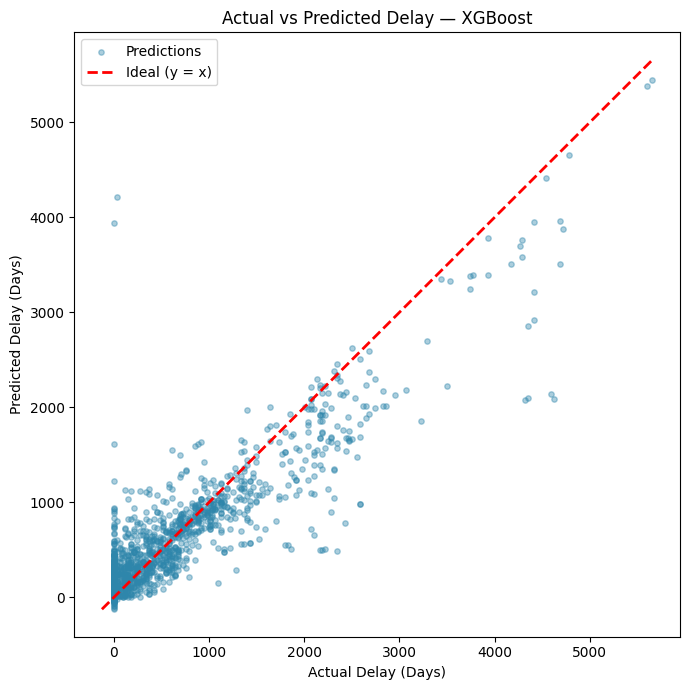

In [ ]:
import matplotlib.pyplot as plt

best_predictions = best_result["pipeline"].predict(X_test)

plt.figure(figsize=(7, 7))
plt.scatter(y_test, best_predictions, alpha=0.4, s=15, color="#2E86AB", label="Predictions")

lims = [min(y_test.min(), best_predictions.min()), max(y_test.max(), best_predictions.max())]
plt.plot(lims, lims, color="red", linestyle="--", linewidth=2, label="Ideal (y = x)")

plt.xlabel("Actual Delay (Days)")
plt.ylabel("Predicted Delay (Days)")
plt.title(f"Actual vs Predicted Delay — {best_model_name}")
plt.legend()
plt.tight_layout()
plt.show()

## 13. Visualization — Random Forest vs XGBoost

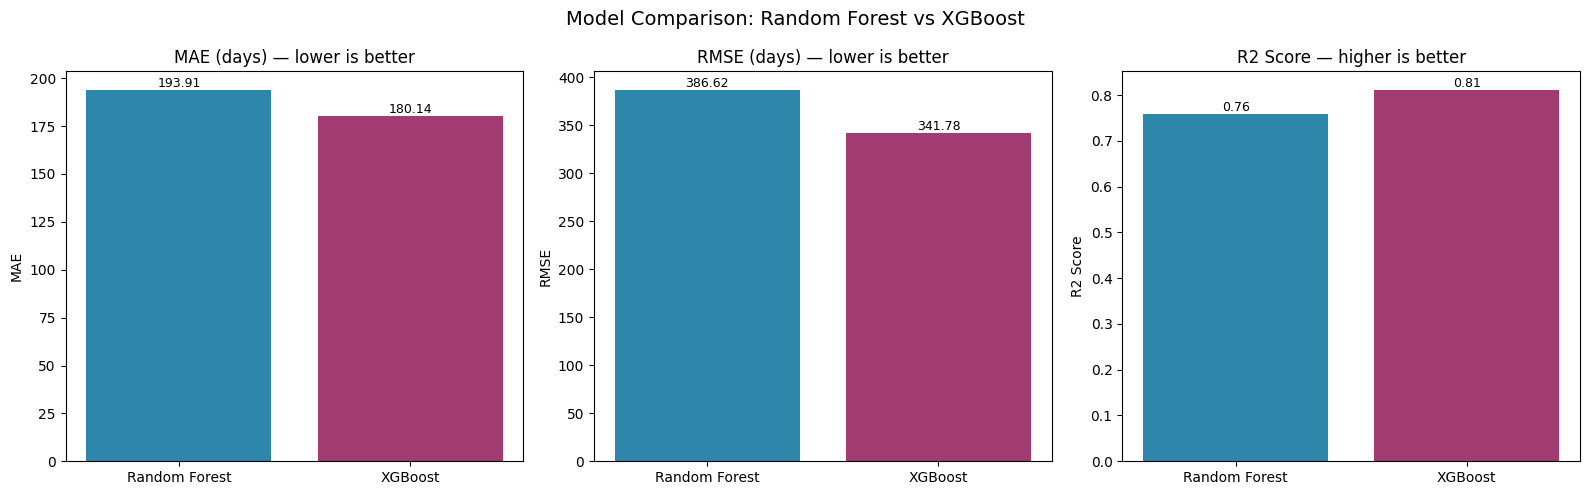

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = [("MAE", "MAE (days) \u2014 lower is better"),
           ("RMSE", "RMSE (days) \u2014 lower is better"),
           ("R2 Score", "R2 Score \u2014 higher is better")]

colors = ["#2E86AB", "#A23B72"]

for ax, (col, title) in zip(axes, metrics):
    bars = ax.bar(comparison_df["Model"], comparison_df[col], color=colors)
    ax.set_title(title)
    ax.set_ylabel(col)
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f"{h:.2f}", (bar.get_x() + bar.get_width() / 2, h),
                    ha="center", va="bottom", fontsize=9)

plt.suptitle("Model Comparison: Random Forest vs XGBoost", fontsize=14)
plt.tight_layout()
plt.show()

## 14. Feature Importance — Top 10

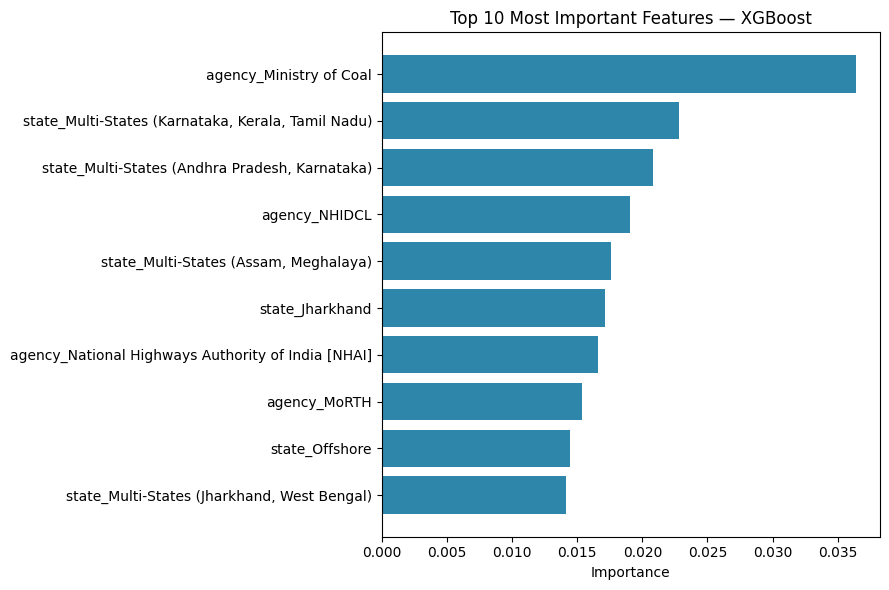

,feature,importance
1248,agency_Ministry of Coal,0.036429
1967,"state_Multi-States (Karnataka, Kerala, Tamil N...",0.022844
1908,"state_Multi-States (Andhra Pradesh, Karnataka)",0.020798
1349,agency_NHIDCL,0.019080
1925,"state_Multi-States (Assam, Meghalaya)",0.017573
1895,state_Jharkhand,0.017152
1365,agency_National Highways Authority of India [N...,0.016578
1260,agency_MoRTH,0.015384
2003,state_Offshore,0.014439
1966,"state_Multi-States (Jharkhand, West Bengal)",0.014105


In [ ]:
def get_feature_names(preprocessor, numerical_features, categorical_features):
    """Reconstruct readable feature names after ColumnTransformer + OneHotEncoder."""
    num_names = list(numerical_features)
    ohe = preprocessor.named_transformers_["cat"].named_steps["onehot"]
    cat_names = list(ohe.get_feature_names_out(categorical_features))
    return num_names + cat_names

fitted_preprocessor = best_pipeline.named_steps["preprocessor"]
feature_names = get_feature_names(fitted_preprocessor, numerical_features, categorical_features)

best_regressor = best_pipeline.named_steps["regressor"]
importances = best_regressor.feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances,
}).sort_values("importance", ascending=False).head(10)

plt.figure(figsize=(9, 6))
plt.barh(importance_df["feature"][::-1], importance_df["importance"][::-1], color="#2E86AB")
plt.xlabel("Importance")
plt.title(f"Top 10 Most Important Features — {best_model_name}")
plt.tight_layout()
plt.show()

importance_df

## 15. Manual Judge Prediction

We demonstrate a prediction for a brand-new, manually entered project. Only the
features that were actually used during training are kept — anything else is
automatically discarded.

In [ ]:
new_project = {
    "project_age_days": 1200,
    "physical_progress_pct": 45,
    "previous_progress": 40,
    "progress_change": 5,
    "original_cost_cr": 500,
    "revised_cost_cr": 650,
    "cumulative_expenditure_cr": 250,
    "previous_expenditure": 220,
    "cost_utilization_pct": 38,
    "expenditure_progress_gap": -7,
    "agency": "Roads & Highways",
    "state": "Himachal Pradesh",
}
# Note: "days_to_original_completion" is intentionally left out — Section 5 found it
# to be a leakage feature, so it is not part of the trained feature list.

# Automatically remove any keys not part of the actual training feature list
new_project_clean = {k: v for k, v in new_project.items() if k in all_features}

new_project_df = pd.DataFrame([new_project_clean])

# Reindex to the full training feature list (any feature not manually supplied
# becomes NaN, and will be safely handled by the pipeline's imputers)
new_project_df = new_project_df.reindex(columns=all_features)
new_project_df

,project_age_days,physical_progress_pct,previous_progress,progress_change,original_cost_cr,revised_cost_cr,cumulative_expenditure_cr,previous_expenditure,expenditure_change,cost_utilization_pct,expenditure_progress_gap,agency,state
0,1200,45,40,5,500,650,250,220,NaN,38,-7,Roads & Highways,Himachal Pradesh


In [ ]:
predicted_delay = best_pipeline.predict(new_project_df)[0]
print(f"Predicted Project Delay (raw model output): {predicted_delay:.1f} days")

# The regressor can output a small negative number, which simply means the model
# expects the project to finish slightly ahead of schedule. For display purposes we
# floor this at 0 days; the raw (possibly negative) value is still what feeds the
# risk classifier below.
display_delay = max(0.0, predicted_delay)
print(f"Predicted Project Delay (display):          {display_delay:.1f} days")

Predicted Project Delay (raw model output): -9.2 days
Predicted Project Delay (display):          0.0 days


## 16. Risk Classification

In [ ]:
def get_risk_level(predicted_delay, low_max=0, medium_max=90):
    """
    Convert a predicted delay (in days) into a risk level.
    Thresholds are kept as parameters so they're easy to adjust.
    """
    if predicted_delay <= low_max:
        return "LOW RISK"
    elif predicted_delay <= medium_max:
        return "MEDIUM RISK"
    else:
        return "HIGH RISK"

risk_level = get_risk_level(predicted_delay)
print("Risk Level:", risk_level)

Risk Level: LOW RISK


## 17. Judge-Friendly Output

In [ ]:
risk_icon = {"LOW RISK": "\U0001F7E2", "MEDIUM RISK": "\U0001F7E1", "HIGH RISK": "\U0001F534"}[risk_level]

print("=" * 60)
print("              PROJECT TIME / DELAY PREDICTION")
print("=" * 60)
print()
print("INPUT GIVEN TO THE MODEL\n")
print(f"Project Age:                {new_project.get('project_age_days', 'N/A')} Days")
print(f"Physical Progress:          {new_project.get('physical_progress_pct', 'N/A')}%")
print(f"Original Cost:              \u20b9{new_project.get('original_cost_cr', 'N/A')} Cr")
print(f"Revised Cost:               \u20b9{new_project.get('revised_cost_cr', 'N/A')} Cr")
print(f"Current Expenditure:        \u20b9{new_project.get('cumulative_expenditure_cr', 'N/A')} Cr")
print(f"Expenditure-Progress Gap:   {new_project.get('expenditure_progress_gap', 'N/A')} pts")
print(f"Agency:                     {new_project.get('agency', 'N/A')}")
print(f"State:                      {new_project.get('state', 'N/A')}")
print()
print("-" * 60)
print()
print("MODEL PREDICTION\n")
print(f"\u23F3 Predicted Project Delay:   {display_delay:.1f} Days")
print()
print(f"{risk_icon} Risk Level:                {risk_level}")
print()
print("-" * 60)
print()
print("MODEL PERFORMANCE\n")
print(f"\U0001F3C6 Best Model:                {best_model_name}")
print()
print(f"MAE:                          {best_mae:.2f} Days")
print(f"RMSE:                         {best_rmse:.2f} Days")
print(f"R\u00b2 Score:                     {best_r2:.4f}")
print()
print("=" * 60)
print()
print("""Based on the project's current age, physical progress, financial progress,
expenditure pattern, remaining completion time, agency, and state, the model
predicts the expected project delay.""")

              PROJECT TIME / DELAY PREDICTION

INPUT GIVEN TO THE MODEL

Project Age:                1200 Days
Physical Progress:          45%
Original Cost:              ₹500 Cr
Revised Cost:               ₹650 Cr
Current Expenditure:        ₹250 Cr
Expenditure-Progress Gap:   -7 pts
Agency:                     Roads & Highways
State:                      Himachal Pradesh

------------------------------------------------------------

MODEL PREDICTION

⏳ Predicted Project Delay:   0.0 Days

🟢 Risk Level:                LOW RISK

------------------------------------------------------------

MODEL PERFORMANCE

🏆 Best Model:                XGBoost

MAE:                          180.14 Days
RMSE:                         341.78 Days
R² Score:                     0.8112


Based on the project's current age, physical progress, financial progress,
expenditure pattern, remaining completion time, agency, and state, the model
predicts the expected project delay.


## 18. Three Realistic Demonstration Scenarios

Each scenario below only uses the actual training features, and the predicted delay
for each one comes directly from the trained pipeline (nothing is hardcoded).

In [ ]:
scenarios = {
    "Healthy Project": {
        "project_age_days": 400,
        "physical_progress_pct": 92,
        "previous_progress": 85,
        "progress_change": 7,
        "original_cost_cr": 300,
        "revised_cost_cr": 300,
        "cumulative_expenditure_cr": 270,
        "previous_expenditure": 240,
        "cost_utilization_pct": 90,
        "expenditure_progress_gap": -2,
        "agency": "Roads & Highways",
        "state": "Himachal Pradesh",
    },
    "Moderate Risk Project": {
        "project_age_days": 1000,
        "physical_progress_pct": 55,
        "previous_progress": 50,
        "progress_change": 5,
        "original_cost_cr": 800,
        "revised_cost_cr": 900,
        "cumulative_expenditure_cr": 500,
        "previous_expenditure": 450,
        "cost_utilization_pct": 56,
        "expenditure_progress_gap": 1,
        "agency": "Roads & Highways",
        "state": "Himachal Pradesh",
    },
    "High Risk Project": {
        "project_age_days": 2200,
        "physical_progress_pct": 20,
        "previous_progress": 18,
        "progress_change": 2,
        "original_cost_cr": 1500,
        "revised_cost_cr": 2100,
        "cumulative_expenditure_cr": 400,
        "previous_expenditure": 380,
        "cost_utilization_pct": 19,
        "expenditure_progress_gap": -1,
        "agency": "Roads & Highways",
        "state": "Himachal Pradesh",
    },
}

scenario_rows = []
for scenario_name, scenario_data in scenarios.items():
    clean_data = {k: v for k, v in scenario_data.items() if k in all_features}
    scenario_df = pd.DataFrame([clean_data]).reindex(columns=all_features)

    pred_delay = best_pipeline.predict(scenario_df)[0]
    risk = get_risk_level(pred_delay)  # risk classification uses the raw (unclipped) prediction

    scenario_rows.append({
        "Scenario": scenario_name,
        "Project Age": scenario_data.get("project_age_days"),
        "Physical Progress": scenario_data.get("physical_progress_pct"),
        "Predicted Delay": round(max(0.0, pred_delay), 1),
        "Risk Level": risk,
    })

scenario_results_df = pd.DataFrame(scenario_rows)
scenario_results_df

,Scenario,Project Age,Physical Progress,Predicted Delay,Risk Level
0,Healthy Project,400,92,205.000000,HIGH RISK
1,Moderate Risk Project,1000,55,30.600000,MEDIUM RISK
2,High Risk Project,2200,20,76.400002,MEDIUM RISK


## 19. Save Final Model

In [ ]:
import joblib
import json

joblib.dump(best_pipeline, "project_time_delay_model.pkl")

metadata = {
    "best_model_name": best_model_name,
    "final_feature_list": all_features,
    "numerical_features": numerical_features,
    "categorical_features": categorical_features,
    "mae": float(best_mae),
    "rmse": float(best_rmse),
    "r2_score": float(best_r2),
    "risk_thresholds": {
        "low_risk_max_days": 0,
        "medium_risk_max_days": 90,
        "high_risk_min_days": 91,
    },
}

with open("project_time_model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

print("Saved model to: project_time_delay_model.pkl")
print("Saved metadata to: project_time_model_metadata.json")
print()
print(json.dumps(metadata, indent=4))

Saved model to: project_time_delay_model.pkl
Saved metadata to: project_time_model_metadata.json

{
    "best_model_name": "XGBoost",
    "final_feature_list": [
        "project_age_days",
        "physical_progress_pct",
        "previous_progress",
        "progress_change",
        "original_cost_cr",
        "revised_cost_cr",
        "cumulative_expenditure_cr",
        "previous_expenditure",
        "expenditure_change",
        "cost_utilization_pct",
        "expenditure_progress_gap",
        "agency",
        "state"
    ],
    "numerical_features": [
        "project_age_days",
        "physical_progress_pct",
        "previous_progress",
        "progress_change",
        "original_cost_cr",
        "revised_cost_cr",
        "cumulative_expenditure_cr",
        "previous_expenditure",
        "expenditure_change",
        "cost_utilization_pct",
        "expenditure_progress_gap"
    ],
    "categorical_features": [
        "agency",
        "state"
    ],
    "mae": 180